# BEV Multi-Camera Train — Phase 1 baseline

Стартовый pipeline на основе [bev_v1.py](bev_v1.py).

Поэтапно:
1. **Sanity** — Dataset и Model выдают правильные формы
2. **Smoke test** — 50 семплов, 3 эпохи, на M1 Pro / CPU. Цель: лосс падает, IoU > 0.
3. **Full train** — переключаешь флаг и запускаешь на V100/A100
4. **Inference** — генерация submission

Что в этой версии:
- ✅ 4 камеры через shared ResNet18 backbone
- ✅ Geometry-aware lift (Simple-BEV style: parameter-free voxel projection через car_to_cam + intrinsic)
- ✅ Правильный resize с пересчётом intrinsic для каждой камеры
- ✅ BCE(pos_weight) + Dice, ignore mask 255
- ✅ Валидация по IoU (как метрика соревнования)

Что **ещё не** в этой версии (Phase 2-3):
- Аугментации (camera dropout, BEV flip)
- Lovasz loss
- TTA, ensemble, threshold tuning
- Pretrained Simple-BEV / DINOv2
- Coverage-aware sampler

In [1]:
%load_ext autoreload
%autoreload 2

import os
# MPS не имеет backward для grid_sample. На M1 fallback на CPU.
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

from pathlib import Path
import time
import csv
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm import tqdm
import matplotlib.pyplot as plt

from bev_v1 import (
    BEVDataset, MultiCamBEV, CompoundLoss,
    iou_binary_batch, compute_pos_weight, compute_coverage_weights,
    BEV_H, BEV_W,
)

# На M1 для smoke test лучше CPU (см. предыдущую заметку про MPS+fallback).
USE_CPU_FOR_SMOKE = True

if torch.cuda.is_available():
    device = torch.device("cuda")
elif USE_CPU_FOR_SMOKE:
    device = torch.device("cpu")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"device = {device}")

DATA_TRAIN = Path("./autonomy_yandex_dataset_train/")
DATA_VAL = Path("./autonomy_yandex_dataset_val/")
DATA_TEST = Path("./autonomy_yandex_dataset_test/")


device = cuda


## 1. Sanity — Dataset выдаёт правильные формы

In [4]:
ds = BEVDataset(DATA_TRAIN, mode="train", img_hw=(384, 768))
print(f"len(train) = {len(ds)}")

sample = ds[0]
for k, v in sample.items():
    if isinstance(v, torch.Tensor):
        print(f"  {k}: {tuple(v.shape)}, {v.dtype}")
    else:
        print(f"  {k}: {v}")

# Проверка значений GT
gt = sample["gt"].numpy()
print(f"  gt unique values: {np.unique(gt)}")
print(f"  gt occupied fraction: {(gt == 1).mean():.3f}, ignore fraction: {(gt == 255).mean():.3f}")

len(train) = 4000
  images: (4, 3, 384, 768), torch.float32
  intrinsics: (4, 3, 3), torch.float32
  car2cams: (4, 4, 4), torch.float32
  gt: (1, 188, 126), torch.int64
  info_idx: 0
  gt unique values: [  0   1 255]
  gt occupied fraction: 0.025, ignore fraction: 0.938


## 2. Sanity — Model forward pass

Проверяем что модель работает на 1 батче из 2 семплов и выдаёт `(2, 1, 188, 126)`.

In [5]:
model = MultiCamBEV().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Model params: {n_params/1e6:.2f}M")

loader = DataLoader(ds, batch_size=2, shuffle=False, num_workers=0)
batch = next(iter(loader))
images = batch["images"].to(device)
intr = batch["intrinsics"].to(device)
c2c = batch["car2cams"].to(device)

with torch.no_grad():
    t0 = time.time()
    logits = model(images, intr, c2c)
    t1 = time.time()
print(f"logits shape = {tuple(logits.shape)}, time = {t1-t0:.2f}s")
assert logits.shape == (2, 1, BEV_H, BEV_W)
print(f"logits stats: min={logits.min().item():.3f}, max={logits.max().item():.3f}, mean={logits.mean().item():.3f}")

Model params: 2.66M
logits shape = (2, 1, 188, 126), time = 2.06s
logits stats: min=-2.270, max=1.395, mean=-0.173


## 3. Smoke test

**Цель**: за 1-2 минуты на M1 / CPU убедиться что:
- лосс падает
- IoU становится > 0 (не модель предсказывающая всегда 0)
- нет NaN, OOM, кривых форм

Если ОК — запускать full train на V100/A100.

In [8]:
# === Конфиг ===
# Меняй PRESET под целевое железо/задачу:
#   "SMOKE"      — локальная отладка на M1/CPU, 64 семпла, 3 эпохи
#   "T4_BUDGET"  — экономный трейн на T4 (~2-3ч): frozen backbone, меньше IMG_HW
#   "T4_FULL"    — полный трейн на T4 (~6-8ч): unfrozen backbone, full data
#   "A100_FINAL" — финальный сильный прогон на A100 (~5-6ч)
PRESET = "T4_BUDGET"

CONFIGS = {
    "SMOKE": dict(
        n_train_samples=64, n_val_samples=16, epochs=3, batch_size=2,
        num_workers=0, img_hw=(256, 512), use_sampler=False, use_amp=False,
        freeze_backbone=False, val_every=1, lr=3e-4,
    ),
    "T4_BUDGET": dict(
        n_train_samples=None, n_val_samples=None, epochs=15, batch_size=6,
        num_workers=4, img_hw=(320, 640), use_sampler=True, use_amp=True,
        freeze_backbone=True, val_every=2, lr=3e-4,
    ),
    "T4_FULL": dict(
        n_train_samples=None, n_val_samples=None, epochs=20, batch_size=6,
        num_workers=4, img_hw=(320, 640), use_sampler=True, use_amp=True,
        freeze_backbone=False, val_every=2, lr=2e-4,
    ),
    "A100_FINAL": dict(
        n_train_samples=None, n_val_samples=None, epochs=25, batch_size=16,
        num_workers=6, img_hw=(384, 768), use_sampler=True, use_amp=True,
        freeze_backbone=False, val_every=1, lr=4e-4,
    ),
}
cfg = CONFIGS[PRESET]
print(f"PRESET = {PRESET}")
for k, v in cfg.items():
    print(f"  {k} = {v}")

WEIGHT_DECAY = 1e-4

# === Output dir ===
RUN_NAME = f"bev_v1_{PRESET.lower()}"
OUT_DIR = Path("./runs") / RUN_NAME
OUT_DIR.mkdir(parents=True, exist_ok=True)
LOG_PATH = OUT_DIR / "log.csv"
CKPT_BEST = OUT_DIR / "best.pt"
CKPT_LAST = OUT_DIR / "last.pt"
print(f"Run dir: {OUT_DIR.resolve()}")

# === Data ===
train_ds_full = BEVDataset(DATA_TRAIN, mode="train", img_hw=cfg["img_hw"])
val_ds = BEVDataset(DATA_VAL, mode="val", img_hw=cfg["img_hw"])

train_ds = train_ds_full
if cfg["n_train_samples"]:
    train_ds = Subset(train_ds, list(range(min(cfg["n_train_samples"], len(train_ds)))))
if cfg["n_val_samples"]:
    val_ds = Subset(val_ds, list(range(min(cfg["n_val_samples"], len(val_ds)))))

# === Coverage-aware sampler ===
sampler = None
if cfg["use_sampler"] and not isinstance(train_ds, Subset):
    weights = compute_coverage_weights(
        DATA_TRAIN / "info.csv",
        cache_path=Path("./runs") / "coverage_weights.npy",  # глобальный кэш
        alpha=0.5, min_weight=0.1,
    )
    print(f"  coverage weights: min={weights.min():.3f}, max={weights.max():.3f}, mean={weights.mean():.3f}")
    sampler = WeightedRandomSampler(
        weights=torch.from_numpy(weights).double(),
        num_samples=len(weights), replacement=True,
    )

train_loader = DataLoader(
    train_ds, batch_size=cfg["batch_size"],
    shuffle=(sampler is None), sampler=sampler,
    num_workers=cfg["num_workers"], drop_last=True, pin_memory=True,
)
val_loader = DataLoader(
    val_ds, batch_size=cfg["batch_size"], shuffle=False,
    num_workers=cfg["num_workers"], pin_memory=True,
)
print(f"train batches: {len(train_loader)}, val batches: {len(val_loader)}")

# === pos_weight ===
if PRESET == "SMOKE":
    pos_weight = 8.0
else:
    print("Computing pos_weight from train (50 batches)...")
    pw_loader = DataLoader(BEVDataset(DATA_TRAIN, "train", cfg["img_hw"]),
                           batch_size=8, shuffle=False, num_workers=2)
    pos_weight = compute_pos_weight(pw_loader, max_batches=50)
    print(f"  pos_weight = {pos_weight:.2f}")

# === Model / Optim / Loss ===
# MODEL_TYPE: "v1" — наш ResNet18 (быстро, ~3M); "v2" — Simple-BEV Encoder_res101 (~40M, pretrained на nuScenes)
MODEL_TYPE = "v2"

if MODEL_TYPE == "v1":
    from bev_v1 import MultiCamBEV
    model = MultiCamBEV(freeze_backbone=cfg["freeze_backbone"]).to(device)
elif MODEL_TYPE == "v2":
    from bev_v2 import MultiCamBEVPretrainedEncoder
    model = MultiCamBEVPretrainedEncoder(
        load_pretrained=True,
        freeze_encoder=cfg["freeze_backbone"],
    ).to(device)
else:
    raise ValueError(MODEL_TYPE)
n_total = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"params: total={n_total/1e6:.2f}M, trainable={n_trainable/1e6:.2f}M (frozen={cfg['freeze_backbone']})")

# Оптимизируем только trainable параметры
trainable_params = [p for p in model.parameters() if p.requires_grad]
optimizer = AdamW(trainable_params, lr=cfg["lr"], weight_decay=WEIGHT_DECAY)
scheduler = CosineAnnealingLR(optimizer, T_max=cfg["epochs"] * len(train_loader))
criterion = CompoundLoss(pos_weight=pos_weight, lambda_dice=0.5).to(device)

# AMP
amp_enabled = cfg["use_amp"] and (device.type == "cuda")
scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)
print(f"AMP enabled: {amp_enabled}")

# === Опционально: загрузка чекпоинта от предыдущего пресета ===
RESUME_FROM = None  # пример: Path("./runs/bev_v1_t4_budget/best.pt")
if RESUME_FROM and Path(RESUME_FROM).exists():
    ckpt = torch.load(RESUME_FROM, map_location=device)
    model.load_state_dict(ckpt["model"], strict=False)
    print(f"resumed from {RESUME_FROM}, prev val_iou = {ckpt.get('val_iou')}")

# Init log file
if not LOG_PATH.exists():
    with open(LOG_PATH, "w") as f:
        csv.writer(f).writerow(["epoch", "train_loss", "val_iou", "lr", "time_s"])

history = {"train_loss": [], "val_iou": []}
best_iou = 0.0


PRESET = T4_BUDGET
  n_train_samples = None
  n_val_samples = None
  epochs = 15
  batch_size = 6
  num_workers = 4
  img_hw = (320, 640)
  use_sampler = True
  use_amp = True
  freeze_backbone = True
  val_every = 2
  lr = 0.0003
Run dir: /home/jupyter/project/runs/bev_v1_t4_budget
  coverage weights: min=0.100, max=0.761, mean=0.506
train batches: 666, val batches: 167
Computing pos_weight from train (50 batches)...
  pos_weight = 1.20


/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


[bev_v2] loaded encoder weights from external/simple_bev/checkpoints/8x5_5e-4_rgb12_22:43:46/model-000025000.pth
  matched: 568 / 568 keys
params: total=39.01M, trainable=1.97M (frozen=True)
AMP enabled: True


In [ ]:
def train_one_epoch(model, loader, opt, sched, criterion, device, scaler, amp_enabled):
    model.train()
    losses = []
    for batch in tqdm(loader, desc="train", leave=False):
        images = batch["images"].to(device, non_blocking=True)
        intr = batch["intrinsics"].to(device, non_blocking=True)
        c2c = batch["car2cams"].to(device, non_blocking=True)
        gt = batch["gt"].to(device, non_blocking=True)

        opt.zero_grad()
        with torch.cuda.amp.autocast(enabled=amp_enabled):
            logits = model(images, intr, c2c)
            loss, parts = criterion(logits, gt)

        if amp_enabled:
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(
                [p for p in model.parameters() if p.requires_grad], 1.0)
            scaler.step(opt)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                [p for p in model.parameters() if p.requires_grad], 1.0)
            opt.step()
        sched.step()
        losses.append(loss.item())
    return float(np.mean(losses))


@torch.no_grad()
def validate(model, loader, device, threshold=0.5, amp_enabled=False):
    model.eval()
    inter_total, union_total = 0, 0
    for batch in tqdm(loader, desc="val", leave=False):
        images = batch["images"].to(device, non_blocking=True)
        intr = batch["intrinsics"].to(device, non_blocking=True)
        c2c = batch["car2cams"].to(device, non_blocking=True)
        gt = batch["gt"].to(device, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=amp_enabled):
            logits = model(images, intr, c2c)
        i, u = iou_binary_batch(logits.float(), gt, threshold=threshold)
        inter_total += i
        union_total += u
    return inter_total / max(union_total, 1)


VAL_EVERY = cfg["val_every"]
N_EPOCHS = cfg["epochs"]

for epoch in range(N_EPOCHS):
    t0 = time.time()
    train_loss = train_one_epoch(
        model, train_loader, optimizer, scheduler, criterion,
        device, scaler, amp_enabled,
    )
    history["train_loss"].append(train_loss)

    do_val = ((epoch + 1) % VAL_EVERY == 0) or (epoch + 1 == N_EPOCHS)
    val_iou = float("nan")
    if do_val:
        val_iou = validate(model, val_loader, device, amp_enabled=amp_enabled)
        history["val_iou"].append(val_iou)

    dt = time.time() - t0
    cur_lr = optimizer.param_groups[0]["lr"]
    val_str = f"val_IoU={val_iou:.4f}" if do_val else "val=skipped"
    print(f"Epoch {epoch+1:3d}/{N_EPOCHS}  loss={train_loss:.4f}  {val_str}  lr={cur_lr:.2e}  ({dt:.1f}s)")

    # CSV log
    with open(LOG_PATH, "a") as f:
        csv.writer(f).writerow([epoch+1, train_loss, val_iou, cur_lr, dt])

    # Save last
    torch.save({
        "model": model.state_dict(), "epoch": epoch+1,
        "val_iou": val_iou if do_val else best_iou,
        "pos_weight": pos_weight, "history": history, "preset": PRESET,
    }, CKPT_LAST)

    # Save best
    if do_val and val_iou > best_iou:
        best_iou = val_iou
        torch.save({
            "model": model.state_dict(), "epoch": epoch+1,
            "val_iou": val_iou, "pos_weight": pos_weight,
            "history": history, "preset": PRESET,
        }, CKPT_BEST)
        print(f"  ★ new best: {best_iou:.4f}  -> {CKPT_BEST}")

print(f"\nFinal best val IoU: {best_iou:.4f}")


train:  25%|██▍       | 166/666 [01:11<02:58,  2.80it/s]

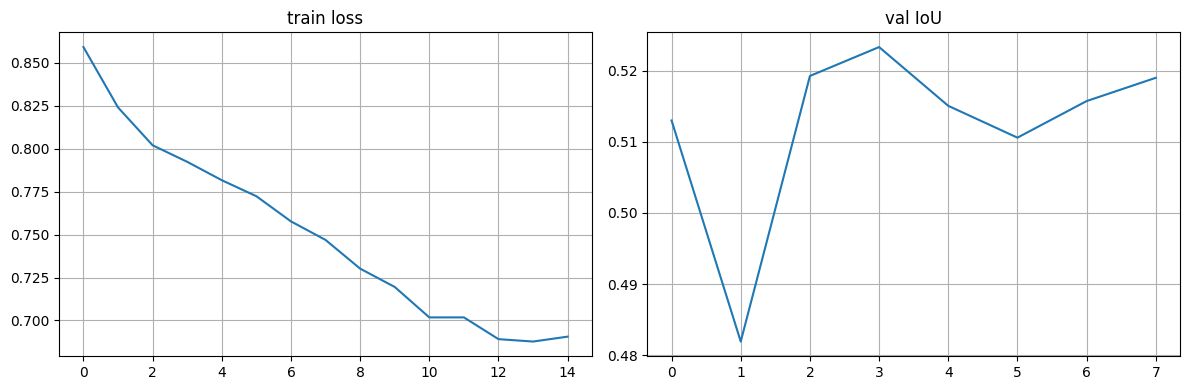

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"]); axes[0].set_title("train loss"); axes[0].grid()
axes[1].plot(history["val_iou"]); axes[1].set_title("val IoU"); axes[1].grid()
plt.tight_layout(); plt.show()

**Что ожидается на smoke test (3 эпохи, 64 семпла, ResNet18 со scratch ImageNet pretrain head)**:
- Лосс падает с ~0.7-1.0 до ~0.5
- val IoU становится > 0 уже после 1-2 эпох (хотя бы 0.05-0.15)
- На 64 семплах высокая метрика не нужна — нужна только динамика

**Если что-то пошло не так**:
- IoU постоянно 0 → модель предсказывает все нули. Проверить `pos_weight` (мб слишком маленький), threshold (мб 0.5 слишком высокий)
- Loss = NaN → проверить что нет деления на 0 в проекции, попробовать lr поменьше
- Loss не падает → проблемы с геометрией (проекция всё-таки кривая) или с данными

In [20]:
# === Загрузка обученного чекпоинта ===
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

from pathlib import Path
import torch
import pandas as pd
import numpy as np
from torch.utils.data import DataLoader

# 1. Где лежит чекпоинт
CKPT_PATH = Path("/home/jupyter/project/bev_v2_ckpt.pt")  # ← поправь под свой путь
# либо ./runs/bev_v1_a100_final/best.pt и т.д.

# 2. Device
device = (
    torch.device("cuda") if torch.cuda.is_available()
    else torch.device("cpu")
)
print(f"device = {device}")

# 3. Загрузка
ckpt = torch.load(CKPT_PATH, map_location=device)
print(f"Checkpoint содержит: {list(ckpt.keys())}")
print(f"  epoch: {ckpt.get('epoch')}")
print(f"  val_iou: {ckpt.get('val_iou')}")
print(f"  pos_weight: {ckpt.get('pos_weight')}")
print(f"  preset (если сохранили): {ckpt.get('preset')}")

# 4. Восстанавливаем модель. Если использовал v1 — MultiCamBEV, если v2 — другой класс.
MODEL_TYPE = "v2"  # ← поправь под то что обучал

if MODEL_TYPE == "v1":
    from bev_v1 import MultiCamBEV, BEVDataset, BEV_H, BEV_W
    model = MultiCamBEV(freeze_backbone=False)
elif MODEL_TYPE == "v2":
    from bev_v2 import MultiCamBEVPretrainedEncoder
    from bev_v1 import BEVDataset, BEV_H, BEV_W
    # Важно: load_pretrained=False — мы загрузим веса из ЧЕКПОИНТА (а не из nuScenes)
    model = MultiCamBEVPretrainedEncoder(load_pretrained=False, freeze_encoder=False)
else:
    raise ValueError(MODEL_TYPE)

model.load_state_dict(ckpt["model"])
model = model.to(device).eval()
print(f"Model loaded. Params: {sum(p.numel() for p in model.parameters())/1e6:.2f}M")

# 5. Восстанавливаем history (если нужны графики)
history = ckpt.get("history", {"train_loss": [], "val_iou": []})
pos_weight = ckpt.get("pos_weight", 5.0)
best_iou = ckpt.get("val_iou", 0.0)

# 6. cfg — если хочешь продолжать тренировку, восстанови ручками под свой preset:
IMG_HW = (320, 640)  # ← поставь то же что было при трейне (для v2 / T4_BUDGET — 320x640)
NUM_WORKERS = 4


device = cuda
Checkpoint содержит: ['model', 'history', 'pos_weight']
  epoch: None
  val_iou: None
  pos_weight: 1.204347582725686
  preset (если сохранили): None


/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Model loaded. Params: 39.01M


## 4. Визуализация предсказаний (для отладки)

Берём 1 батч валидации, печатаем pred / GT / разницу. Помогает понять **что именно** модель путает.

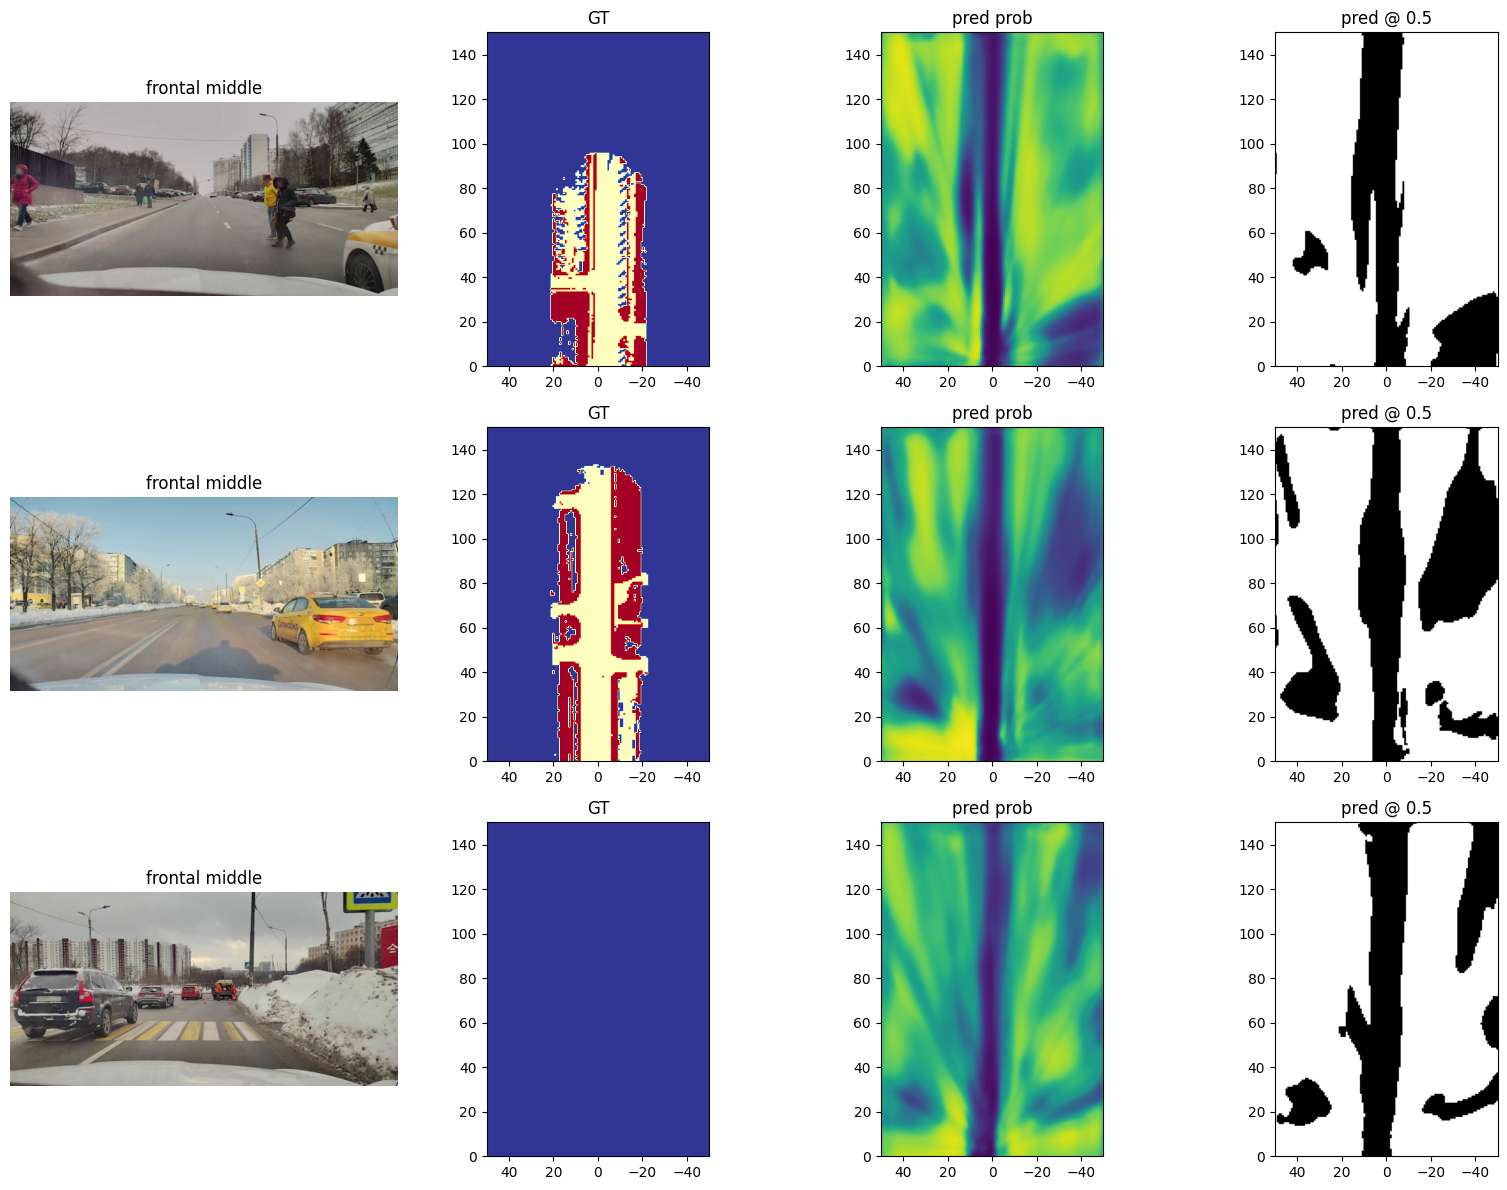

In [21]:
model.eval()
with torch.no_grad():
    batch = next(iter(val_loader))
    images = batch["images"].to(device)
    intr = batch["intrinsics"].to(device)
    c2c = batch["car2cams"].to(device)
    gt = batch["gt"]
    logits = model(images, intr, c2c).cpu()
    probs = torch.sigmoid(logits)

n = min(3, images.shape[0])
fig, axes = plt.subplots(n, 4, figsize=(16, 4*n))
if n == 1: axes = axes[None, :]
extent = [-50, 50, 0, 150]
for k in range(n):
    # Camera middle
    img_norm = images[k, 0].cpu().permute(1, 2, 0).numpy()
    img_show = img_norm * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    axes[k, 0].imshow(np.clip(img_show, 0, 1))
    axes[k, 0].set_title("frontal middle")
    axes[k, 0].axis("off")
    # GT
    g = gt[k, 0].numpy().astype(np.float32)
    g[g == 255] = -1
    axes[k, 1].imshow(g, cmap="RdYlBu_r", extent=extent, origin="lower", vmin=-1, vmax=1)
    axes[k, 1].invert_xaxis(); axes[k, 1].set_title("GT")
    # Probs
    p = probs[k, 0].numpy()
    axes[k, 2].imshow(p, cmap="viridis", extent=extent, origin="lower", vmin=0, vmax=1)
    axes[k, 2].invert_xaxis(); axes[k, 2].set_title("pred prob")
    # Pred binary
    pb = (p > 0.5).astype(np.float32)
    axes[k, 3].imshow(pb, cmap="gray", extent=extent, origin="lower")
    axes[k, 3].invert_xaxis(); axes[k, 3].set_title("pred @ 0.5")
plt.tight_layout(); plt.show()

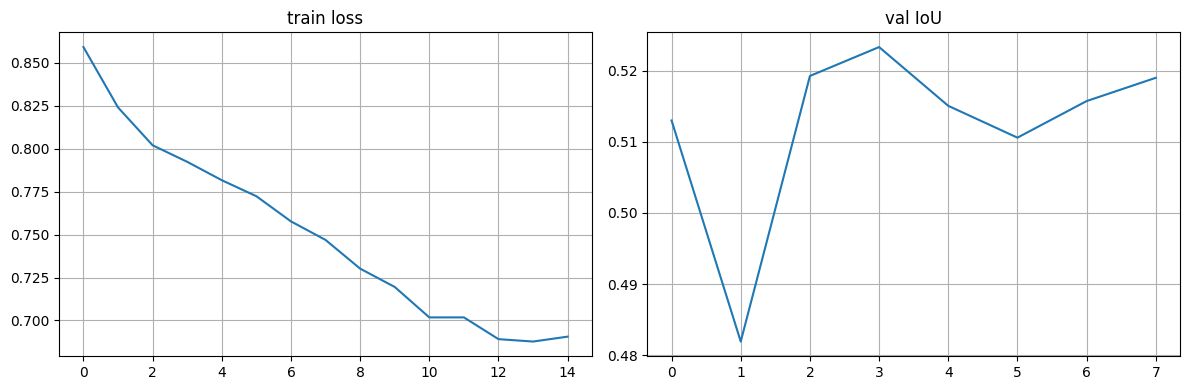

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"]); axes[0].set_title("train loss"); axes[0].grid()
axes[1].plot(history["val_iou"]); axes[1].set_title("val IoU"); axes[1].grid()
plt.tight_layout(); plt.show()

## 5. Full train

После того как smoke test зелёный — копируем этот ноутбук на удалённый GPU (V100 / A100) и переключаем `SMOKE_TEST = False`. Сохраняем чекпоинты, валидируемся на полном val.

Дополнительные шаги для full train (добавить позже):
- Save best checkpoint by val IoU
- Threshold sweep на val
- EMA weights
- Графики обучения
- Логирование (wandb / tensorboard / просто print)

In [8]:
# Save model after training
CKPT_PATH = Path("./bev_v2_ckpt.pt")
torch.save({
    "model": model.state_dict(),
    "history": history,
    "pos_weight": pos_weight,
}, CKPT_PATH)
print(f"saved to {CKPT_PATH}")

saved to bev_v2_ckpt.pt


In [ ]:
CKPT_PATH

## 6. Inference на test → submission

Генерируем `predicted_static_grids/*.npy` в формате (1, 188, 126) int32 со значениями 0/1, упаковываем в zip согласно требованиям.

In [23]:
# Threshold подбираем по val (после full train)
@torch.no_grad()
def find_best_threshold(model, loader, device, thresholds=None):
    if thresholds is None:
        thresholds = np.linspace(0.2, 0.7, 21)
    model.eval()
    # cache logits
    all_logits, all_gt = [], []
    for batch in tqdm(loader, desc="threshold sweep"):
        images = batch["images"].to(device)
        intr = batch["intrinsics"].to(device)
        c2c = batch["car2cams"].to(device)
        logits = model(images, intr, c2c).cpu()
        all_logits.append(logits)
        all_gt.append(batch["gt"])
    all_logits = torch.cat(all_logits)
    all_gt = torch.cat(all_gt)
    best_iou, best_t = 0, 0.5
    for t in thresholds:
        i, u = iou_binary_batch(all_logits, all_gt, threshold=float(t))
        iou = i / max(u, 1)
        if iou > best_iou: best_iou, best_t = iou, float(t)
    return best_t, best_iou

# Раскомментировать после full train
best_t, best_iou = find_best_threshold(model, val_loader, device)
print(f"best threshold: {best_t}, val IoU = {best_iou:.4f}")
best_t

threshold sweep: 100%|██████████| 167/167 [01:37<00:00,  1.71it/s]


best threshold: 0.325, val IoU = 0.5331


0.325

In [24]:
best_t = BEST_T_SAVE

In [29]:
best_t = 0.325

In [30]:
# === Predict on test ===
import shutil

test_ds = BEVDataset(DATA_TEST, mode="test", img_hw=cfg["img_hw"])
test_loader = DataLoader(test_ds, batch_size=4, shuffle=False, num_workers=cfg["num_workers"])
test_info = pd.read_csv(DATA_TEST / "info.csv", index_col=0)

(DATA_TEST / "predicted_static_grids").mkdir(exist_ok=True)

# Опционально: загрузить best checkpoint перед инференсом
LOAD_BEST_FOR_INFER = True
if LOAD_BEST_FOR_INFER and CKPT_BEST.exists():
    ckpt = torch.load(CKPT_BEST, map_location=device)
    model.load_state_dict(ckpt["model"])
    print(f"loaded {CKPT_BEST}, val_iou = {ckpt.get('val_iou')}")

model.eval()
with torch.no_grad():
    for batch in tqdm(test_loader, desc="test inference"):
        images = batch["images"].to(device)
        intr = batch["intrinsics"].to(device)
        c2c = batch["car2cams"].to(device)
        idxs = batch["info_idx"]
        with torch.cuda.amp.autocast(enabled=amp_enabled):
            logits = model(images, intr, c2c)
        preds = (torch.sigmoid(logits.float()) > best_t).cpu().numpy().astype(np.int32)
        for k, i in enumerate(idxs):
            out_path = test_info.iloc[i.item()]["predicted_occupancy_grid"]
            grid = preds[k].reshape(1, BEV_H, BEV_W)
            np.save(out_path, grid)

print("all predictions saved.")


loaded runs/bev_v1_t4_budget/best.pt, val_iou = 0.5233457404908343


test inference: 100%|██████████| 500/500 [02:29<00:00,  3.34it/s]

all predictions saved.


In [31]:
# === Pack submission (надёжный сборщик) ===
import zipfile
import hashlib

SUBMISSION_NAME = "submission_v13.zip"

# 1. Sanity: проверим что info.csv существует и что для каждой строки info.csv
#    есть соответствующий predicted .npy
print("Verifying predictions...")
test_info_check = pd.read_csv(DATA_TEST / "info.csv", index_col=0)
missing = []
shape_bad = []
for i, row in test_info_check.iterrows():
    pred_path = Path(row["predicted_occupancy_grid"])
    if not pred_path.exists():
        missing.append(str(pred_path))
        continue
    try:
        arr = np.load(pred_path)
        if arr.shape != (1, BEV_H, BEV_W) or set(np.unique(arr).tolist()) - {0, 1}:
            shape_bad.append(f"{pred_path}: shape={arr.shape}, unique={np.unique(arr)}")
    except Exception as e:
        shape_bad.append(f"{pred_path}: {e}")

if missing:
    print(f"!! {len(missing)} missing predictions, e.g. {missing[:3]}")
    raise RuntimeError("Не все предсказания сохранены — заново запусти клетку inference")
if shape_bad:
    print(f"!! {len(shape_bad)} predictions с неправильной формой/значениями, e.g. {shape_bad[:3]}")
    raise RuntimeError("Предсказания должны быть shape (1,188,126), значения {0,1}")
print(f"  OK: {len(test_info_check)} predictions, all valid")

# 2. Собираем zip напрямую через zipfile (надёжнее чем shutil.make_archive)
sub_path = Path(SUBMISSION_NAME)
if sub_path.exists():
    sub_path.unlink()

print(f"Building {sub_path}...")
files_added = 0
with zipfile.ZipFile(sub_path, "w", compression=zipfile.ZIP_DEFLATED, compresslevel=6) as zf:
    # info.csv в корне
    zf.write(DATA_TEST / "info.csv", arcname="info.csv")
    files_added += 1
    # все .npy из predicted_static_grids/
    pred_dir = DATA_TEST / "predicted_static_grids"
    for npy in sorted(pred_dir.glob("*.npy")):
        zf.write(npy, arcname=f"predicted_static_grids/{npy.name}")
        files_added += 1

print(f"  added {files_added} files to {sub_path}")

# 3. Проверка целостности — переоткрываем и читаем все entries
print("Verifying zip integrity...")
with zipfile.ZipFile(sub_path, "r") as zf:
    bad = zf.testzip()
    if bad is not None:
        raise RuntimeError(f"Bad zip entry: {bad}")
    names = zf.namelist()
    print(f"  zip contains {len(names)} entries")
    print(f"  first 3: {names[:3]}")
    print(f"  contains info.csv: {'info.csv' in names}")
    n_pred = sum(1 for n in names if n.startswith('predicted_static_grids/'))
    print(f"  predicted_static_grids entries: {n_pred}")

# 4. Print size + SHA256 (используй чтобы убедиться что после загрузки файл целый)
size = sub_path.stat().st_size
h = hashlib.sha256()
with open(sub_path, "rb") as f:
    for chunk in iter(lambda: f.read(1 << 20), b""):
        h.update(chunk)
print(f"\n=== SUBMISSION READY ===")
print(f"  path:   {sub_path.resolve()}")
print(f"  size:   {size/1e6:.2f} MB")
print(f"  sha256: {h.hexdigest()}")
print(f"\nЕсли после загрузки на сервер sha256 совпадает — файл целый.")


Verifying predictions...
  OK: 2000 predictions, all valid
Building submission_v13.zip...
  added 2001 files to submission_v13.zip
Verifying zip integrity...
  zip contains 2001 entries
  first 3: ['info.csv', 'predicted_static_grids/1626973770133886000_lerita_grid.npy', 'predicted_static_grids/1627452392034388000_hilma_grid.npy']
  contains info.csv: True
  predicted_static_grids entries: 2000

=== SUBMISSION READY ===
  path:   /home/jupyter/project/submission_v13.zip
  size:   2.41 MB
  sha256: 2980cc28623ef725b17839b9feaf567aa63f78e99314882b5a62e872b121644e

Если после загрузки на сервер sha256 совпадает — файл целый.


In [11]:
!unzip submission_v1.zip

Archive:  submission_v1.zip
  inflating: info.csv                
  inflating: predicted_static_grids/1626973770133886000_lerita_grid.npy  
  inflating: predicted_static_grids/1627452392034388000_hilma_grid.npy  
  inflating: predicted_static_grids/1627452401033852000_hilma_grid.npy  
  inflating: predicted_static_grids/1628187009733993000_shelly_grid.npy  
  inflating: predicted_static_grids/1628187011533987000_shelly_grid.npy  
  inflating: predicted_static_grids/1628187013334048000_shelly_grid.npy  
  inflating: predicted_static_grids/1628264965033751000_orvy_grid.npy  
  inflating: predicted_static_grids/1628266092833777000_orvy_grid.npy  
  inflating: predicted_static_grids/1628266103434020000_orvy_grid.npy  
  inflating: predicted_static_grids/1628266117733961000_orvy_grid.npy  
  inflating: predicted_static_grids/1628266121933750000_orvy_grid.npy  
  inflating: predicted_static_grids/1628266382133892000_orvy_grid.npy  
  inflating: predicted_static_grids/1628266386033838000_orvy